## 1. Load Data

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('Breast_cancer_Dataset.csv')
print(df.shape)
df.head()

(683, 11)


,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


## 2. Features & Target
`Sample code number` is just an ID column, so it is dropped. `Class` is the target (2 = benign, 4 = malignant).

In [2]:
X = df.drop(columns=['Sample code number', 'Class']).values
y = df['Class'].values
print(X.shape, y.shape)

(683, 9) (683,)


## 3. Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (546, 9)  Test: (137, 9)


## 4. Feature Scaling
Distance-based models (KNN, SVM) need scaled features; tree-based models don't strictly need it but it doesn't hurt.

In [4]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

## 5. Results Tracker
Store accuracy for each model so we can compare them at the end.

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix

results = {}

---
## Model 1 — Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=0, max_iter=1000)
log_reg.fit(X_train_sc, y_train)

y_pred = log_reg.predict(X_test_sc)
results['Logistic Regression'] = accuracy_score(y_test, y_pred)
print("Accuracy:", results['Logistic Regression'])

Accuracy: 0.948905109489051


---
## Model 2 — K-Nearest Neighbors

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)

y_pred = knn.predict(X_test_sc)
results['KNN'] = accuracy_score(y_test, y_pred)
print("Accuracy:", results['KNN'])

Accuracy: 0.948905109489051


---
## Model 3 — Support Vector Machine (SVM, RBF kernel)

In [8]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=0)
svm.fit(X_train_sc, y_train)

y_pred = svm.predict(X_test_sc)
results['SVM (RBF)'] = accuracy_score(y_test, y_pred)
print("Accuracy:", results['SVM (RBF)'])

Accuracy: 0.9562043795620438


---
## Model 4 — Naive Bayes

In [9]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_sc, y_train)

y_pred = nb.predict(X_test_sc)
results['Naive Bayes'] = accuracy_score(y_test, y_pred)
print("Accuracy:", results['Naive Bayes'])

Accuracy: 0.948905109489051


---
## Model 5 — Decision Tree

In [10]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(criterion='entropy', random_state=0)
tree_clf.fit(X_train, y_train)

y_pred = tree_clf.predict(X_test)
results['Decision Tree'] = accuracy_score(y_test, y_pred)
print("Accuracy:", results['Decision Tree'])

Accuracy: 0.9124087591240876


---
## Model 6 — Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, y_pred)
print("Accuracy:", results['Random Forest'])

Accuracy: 0.948905109489051


---
## Final Comparison
All 6 classification models side by side, sorted from best to worst accuracy.

In [12]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy
0,SVM (RBF),0.956204
1,Logistic Regression,0.948905
2,KNN,0.948905
3,Naive Bayes,0.948905
4,Random Forest,0.948905
5,Decision Tree,0.912409


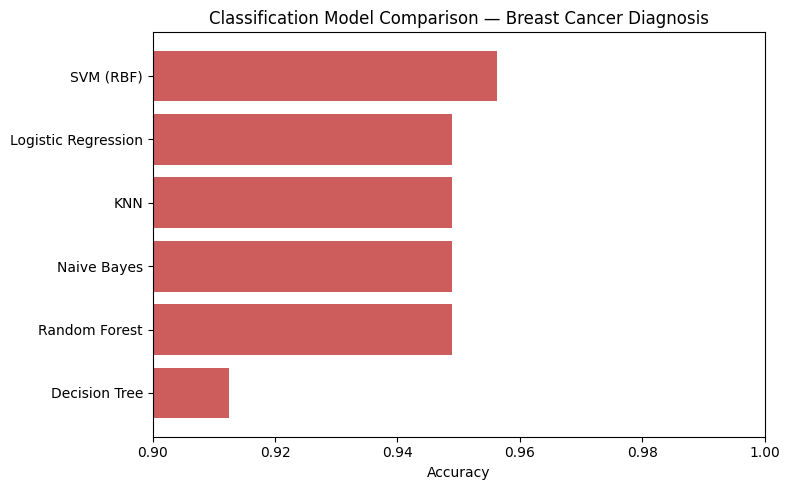

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(results_df['Model'], results_df['Accuracy'], color='indianred')
plt.xlabel('Accuracy')
plt.title('Classification Model Comparison — Breast Cancer Diagnosis')
plt.xlim(0.9, 1.0)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Best Model — Confusion Matrix

In [14]:
best_model_name = results_df.iloc[0]['Model']
print("Best model:", best_model_name)

model_lookup = {
    'Logistic Regression': (log_reg, X_test_sc),
    'KNN': (knn, X_test_sc),
    'SVM (RBF)': (svm, X_test_sc),
    'Naive Bayes': (nb, X_test_sc),
    'Decision Tree': (tree_clf, X_test),
    'Random Forest': (rf_clf, X_test),
}
best_model, best_X_test = model_lookup[best_model_name]
y_pred_best = best_model.predict(best_X_test)
cm = confusion_matrix(y_test, y_pred_best)
print(cm)

Best model: SVM (RBF)
[[85  4]
 [ 2 46]]
